# CBIS-DDSM Original

This is the complete dataset, downloaded from https://www.cancerimagingarchive.net/collection/cbis-ddsm/

In [105]:
from pathlib import Path

import pandas as pd
import pydicom
import matplotlib.pyplot as plt

In [39]:
DATASET_ROOT = Path("../datasets/CBIS-DDSM")
IMG_ROOT = DATASET_ROOT / "CBIS-DDSM"

In [41]:
train_mass_df = pd.read_csv(DATASET_ROOT / "mass_case_description_train_set.csv")
train_mass_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [42]:
train_calc_df = pd.read_csv(DATASET_ROOT / "calc_case_description_train_set.csv")
train_calc_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [59]:
raw_img = train_calc_df.iloc[0]["image file path"].strip()

In [60]:
raw_img

'Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.408909860712120272633130274602115723157/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/000000.dcm'

In [109]:
roi_mask_path_img = train_calc_df.iloc[0]["ROI mask file path"].strip()
roi_mask_path_img

'Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/000000.dcm'

In [110]:
cropped_img = train_calc_df.iloc[0]["cropped image file path"].strip()
cropped_img

'Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/000001.dcm'

In [67]:
cropped_subject_id = cropped_img.split("/")[0]
cropped_subject_id

'Calc-Training_P_00005_RIGHT_CC_1'

In [83]:
cropped_study_uid = cropped_img.split("/")[1]
cropped_study_uid

'1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081'

In [78]:
cropped_series_uid = cropped_img.split("/")[2]
cropped_series_uid

'1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682'

In [118]:
img_num = int(cropped_img.split("/")[-1].replace(".dcm", "")[-1]) + 1
img_num

2

In [68]:
metadata_df = pd.read_csv(DATASET_ROOT / "metadata.csv")

In [72]:
metadata_df["Subject ID"].nunique()

6671

In [73]:
len(metadata_df)

6775

In [85]:
cropped_meta = metadata_df[
    (metadata_df["Subject ID"] == cropped_subject_id) &
    (metadata_df["Series UID"] == cropped_series_uid) &
    (metadata_df["Study UID"] == cropped_study_uid)
].iloc[0]

In [86]:
dict(cropped_meta)

{'Series UID': '1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682',
 'Collection': 'CBIS-DDSM',
 '3rd Party Analysis': np.float64(nan),
 'Data Description URI': 'https://doi.org/10.7937/K9/TCIA.2016.7O02S9CY',
 'Subject ID': 'Calc-Training_P_00005_RIGHT_CC_1',
 'Study UID': '1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081',
 'Study Description': np.float64(nan),
 'Study Date': '08-30-2017',
 'Series Description': 'cropped images',
 'Manufacturer': np.float64(nan),
 'Modality': 'MG',
 'SOP Class Name': 'Secondary Capture Image Storage',
 'SOP Class UID': '1.2.840.10008.5.1.4.1.1.7',
 'Number of Images': np.int64(2),
 'File Size': '14.76 MB',
 'File Location': './CBIS-DDSM/Calc-Training_P_00005_RIGHT_CC_1/08-30-2017-DDSM-NA-09081/1.000000-cropped images-94682',
 'Download Timestamp': '2025-11-25T06:07:15.708'}

In [96]:
img_path = DATASET_ROOT / cropped_meta["File Location"]
img_path

PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Calc-Training_P_00005_RIGHT_CC_1/08-30-2017-DDSM-NA-09081/1.000000-cropped images-94682')

In [102]:
files = list(img_path.rglob("[!.]*.dcm"))
list(files)

[PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Calc-Training_P_00005_RIGHT_CC_1/08-30-2017-DDSM-NA-09081/1.000000-cropped images-94682/1-1.dcm'),
 PosixPath('../datasets/CBIS-DDSM/CBIS-DDSM/Calc-Training_P_00005_RIGHT_CC_1/08-30-2017-DDSM-NA-09081/1.000000-cropped images-94682/1-2.dcm')]

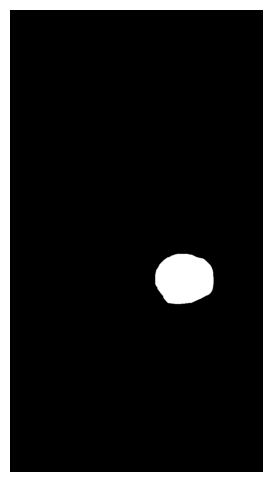

In [107]:
ds = pydicom.dcmread(files[0])
img = ds.pixel_array

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

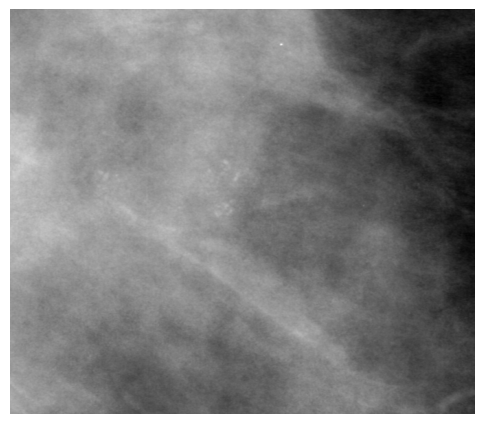

In [108]:
ds = pydicom.dcmread(files[1])
img = ds.pixel_array

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()